# Logprob Threshold Analysis

Determines whether logprob-derived confidence from the LLM classifier improves on self-reported `clf_confidence` for thresholding in the hybrid pipeline.

**Key insight**: The JSON output splits labels across sub-word tokens (`"ad"` + `"vers"` + `"arial"`). The label-start token (position 4 in clf, after `_label` in judge) carries the discriminative signal — its logprob and margin to the second-best token indicate model certainty.

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
pd.set_option("display.max_colwidth", 120)

if Path.cwd().name == "notebooks":
    ROOT = Path.cwd().parent
else:
    ROOT = Path.cwd()

LLM_PATH = ROOT / "data/processed/predictions/llm_predictions_test.parquet"
RESEARCH_PATH = ROOT / "data/processed/research/research_test.parquet"

print(f"ROOT: {ROOT}")
print(f"LLM exists: {LLM_PATH.exists()}")
print(f"Research exists: {RESEARCH_PATH.exists()}")

ROOT: /Users/noamc/repos/llm-gatekeeping
LLM exists: True
Research exists: True


In [2]:
# Load and merge datasets
llm_df = pd.read_parquet(LLM_PATH)
research_df = pd.read_parquet(RESEARCH_PATH)

df = research_df.merge(llm_df[["sample_id", "clf_token_logprobs", "judge_token_logprobs"]],
                       on="sample_id", how="left")
df["llm_correct"] = df["llm_pred_binary"] == df["label_binary"]
df["hybrid_correct"] = df["hybrid_pred_binary"] == df["label_binary"]
print(f"Merged: {len(df)} rows, {df['label_binary'].value_counts().to_dict()}")
print(f"LLM stages: {df['llm_stages_run'].value_counts().to_dict()}")
print(f"Hybrid routing: {df['hybrid_routed_to'].value_counts().to_dict()}")

Merged: 1819 rows, {'adversarial': 1682, 'benign': 137}
LLM stages: {2: 1328, 1: 491}
Hybrid routing: {'ml': 928, 'llm': 868, 'abstain': 23}


## Section 2: Token Stream Parser

The classifier JSON schema is fixed: `{"label": "<value>", "confidence": <int>, ...}`

- **clf tokens**: `[0]={"` `[1]=label` `[2]=":` `[3]= "` `[4]=label_start` (e.g. `ad` or `ben`). Token names in `top_logprobs` are **empty** (NIM limitation) but logprob values are preserved.
- **judge tokens**: variable-length preamble; find `_label` key, then skip `":` and `" ` to reach label start. Token names in `top_logprobs` **are** present (e.g. `('ad', -0.001), ('ben', -7.001)`).

In [3]:
def _safe_json_loads(value):
    """Parse JSON from various storage formats."""
    if value is None:
        return None
    if isinstance(value, float) and math.isnan(value):
        return None
    if isinstance(value, (list, dict)):
        return value
    if not isinstance(value, str):
        return None
    value = value.strip()
    if not value or value in {"null", "None", "nan", "NaN"}:
        return None
    try:
        return json.loads(value)
    except json.JSONDecodeError:
        return None


def _find_label_start_idx(tokens, mode="clf"):
    """Find the index of the label-start token in the token stream.

    clf mode: fixed position 4 (after {"  label  ":  " )
    judge mode: find '_label' token, then skip '":' and ' "' to reach value.
    """
    if mode == "clf":
        return 4 if len(tokens) > 4 else None

    # Judge: search for _label key
    for i, tok in enumerate(tokens):
        t = tok.get("token", "")
        if t == "_label":
            # Expect '":' then ' "' then label value
            candidate = i + 3
            if candidate < len(tokens):
                return candidate
    return None


def _label_end_idx(tokens, start_idx):
    """Find the end of the label value tokens (up to closing quote or comma)."""
    for i in range(start_idx, min(len(tokens), start_idx + 5)):
        t = tokens[i].get("token", "")
        if '"' in t and i > start_idx:
            return i  # exclusive
        if t.startswith('",') or t.startswith('"'):
            if i == start_idx:
                continue  # skip if it's the start token itself
            return i
    return min(start_idx + 3, len(tokens))  # fallback: assume 3 sub-tokens max


def _find_confidence_token_idx(tokens, mode="clf"):
    """Find the index of the confidence value token."""
    if mode == "clf":
        # Fixed: position 12 (after ..., "confidence": <space>)
        return 12 if len(tokens) > 12 else None

    # Judge: search for 'confidence' key token, skip '":' and ' '
    for i, tok in enumerate(tokens):
        t = tok.get("token", "")
        if "confidence" in t.lower():
            candidate = i + 3  # skip '":' ' ' to reach value
            if candidate < len(tokens):
                return candidate
    return None


def extract_logprob_features(raw_payload, mode="clf"):
    """Extract logprob-derived features from a token stream.

    Returns dict with:
    - label_start_logprob: logprob of first label value token
    - label_start_margin: top_logprobs[0].logprob - top_logprobs[1].logprob
    - label_sum_logprob: sum of logprobs across all label sub-tokens
    - confidence_token_logprob: logprob of the confidence value token
    - mean_logprob, min_logprob: aggregates over full response
    """
    tokens = _safe_json_loads(raw_payload)
    features = {
        "label_start_logprob": np.nan,
        "label_start_prob": np.nan,
        "label_start_margin": np.nan,
        "label_sum_logprob": np.nan,
        "confidence_token_logprob": np.nan,
        "mean_logprob": np.nan,
        "min_logprob": np.nan,
        "token_count": np.nan,
        "has_signal": False,
    }
    if not isinstance(tokens, list) or len(tokens) < 5:
        return features

    # Aggregate stats
    all_lps = [t.get("logprob") for t in tokens
               if isinstance(t.get("logprob"), (int, float))]
    if all_lps:
        features["mean_logprob"] = float(np.mean(all_lps))
        features["min_logprob"] = float(np.min(all_lps))
        features["token_count"] = float(len(all_lps))

    # Label start token
    label_idx = _find_label_start_idx(tokens, mode=mode)
    if label_idx is None or label_idx >= len(tokens):
        return features

    label_tok = tokens[label_idx]
    lp = label_tok.get("logprob")
    if not isinstance(lp, (int, float)):
        return features

    features["label_start_logprob"] = float(lp)
    features["label_start_prob"] = float(np.exp(lp))
    features["has_signal"] = True

    # Margin: difference between rank-1 and rank-2 in top_logprobs
    top = label_tok.get("top_logprobs") or []
    top_lps = sorted(
        [float(t.get("logprob")) for t in top if isinstance(t.get("logprob"), (int, float))],
        reverse=True,
    )
    if len(top_lps) >= 2:
        features["label_start_margin"] = top_lps[0] - top_lps[1]

    # Sum logprob across all label sub-tokens
    end_idx = _label_end_idx(tokens, label_idx)
    label_lps = []
    for i in range(label_idx, end_idx):
        tok_lp = tokens[i].get("logprob")
        if isinstance(tok_lp, (int, float)):
            label_lps.append(float(tok_lp))
    if label_lps:
        features["label_sum_logprob"] = sum(label_lps)

    # Confidence token
    conf_idx = _find_confidence_token_idx(tokens, mode=mode)
    if conf_idx is not None and conf_idx < len(tokens):
        conf_lp = tokens[conf_idx].get("logprob")
        if isinstance(conf_lp, (int, float)):
            features["confidence_token_logprob"] = float(conf_lp)

    return features


# Test on first row
sample = df.iloc[0]["clf_token_logprobs"]
print("Sample clf features:", extract_logprob_features(sample, mode="clf"))
sample_j = df.iloc[0]["judge_token_logprobs"]
print("Sample judge features:", extract_logprob_features(sample_j, mode="judge"))

Sample clf features: {'label_start_logprob': -0.12833698, 'label_start_prob': 0.8795569361034329, 'label_start_margin': 2.0000000200000003, 'label_sum_logprob': -0.128356410964, 'confidence_token_logprob': -0.00013934595, 'mean_logprob': -0.007982568773674509, 'min_logprob': -0.25124052, 'token_count': 51.0, 'has_signal': True}
Sample judge features: {'label_start_logprob': -0.0010253892978653312, 'label_start_prob': 0.9989751362341005, 'label_start_margin': 6.999999810592271, 'label_sum_logprob': -0.0010258661349098475, 'confidence_token_logprob': nan, 'mean_logprob': -0.023006723304370025, 'min_logprob': -1.2887402772903442, 'token_count': 234.0, 'has_signal': True}


In [4]:
# Apply parser to both clf and judge, then select preferred stage (judge when available)
clf_feats = df["clf_token_logprobs"].apply(lambda x: extract_logprob_features(x, mode="clf")).apply(pd.Series)
clf_feats = clf_feats.add_prefix("clf_")

judge_feats = df["judge_token_logprobs"].apply(lambda x: extract_logprob_features(x, mode="judge")).apply(pd.Series)
judge_feats = judge_feats.add_prefix("judge_")

df = pd.concat([df, clf_feats, judge_feats], axis=1)

# Preferred stage: use judge when available (judge ran on low-confidence cases), else clf
has_judge = df["judge_has_signal"].fillna(False).astype(bool)
for feat in ["label_start_logprob", "label_start_prob", "label_start_margin",
             "label_sum_logprob", "confidence_token_logprob", "mean_logprob", "min_logprob"]:
    df[f"pref_{feat}"] = np.where(has_judge, df[f"judge_{feat}"], df[f"clf_{feat}"])

df["pref_stage"] = np.where(has_judge, "judge", "clf")
df["pref_has_signal"] = df["clf_has_signal"].fillna(False) | df["judge_has_signal"].fillna(False)

print(f"clf signal: {df['clf_has_signal'].sum()}/{len(df)} ({df['clf_has_signal'].mean():.1%})")
print(f"judge signal: {df['judge_has_signal'].sum()}/{len(df)} ({df['judge_has_signal'].mean():.1%})")
print(f"preferred signal: {df['pref_has_signal'].sum()}/{len(df)} ({df['pref_has_signal'].mean():.1%})")
print(f"preferred stage: {df['pref_stage'].value_counts().to_dict()}")

clf signal: 1589/1819 (87.4%)
judge signal: 1305/1819 (71.7%)
preferred signal: 1809/1819 (99.5%)
preferred stage: {'judge': 1305, 'clf': 514}


## Section 3: Signal Coverage & Distributions

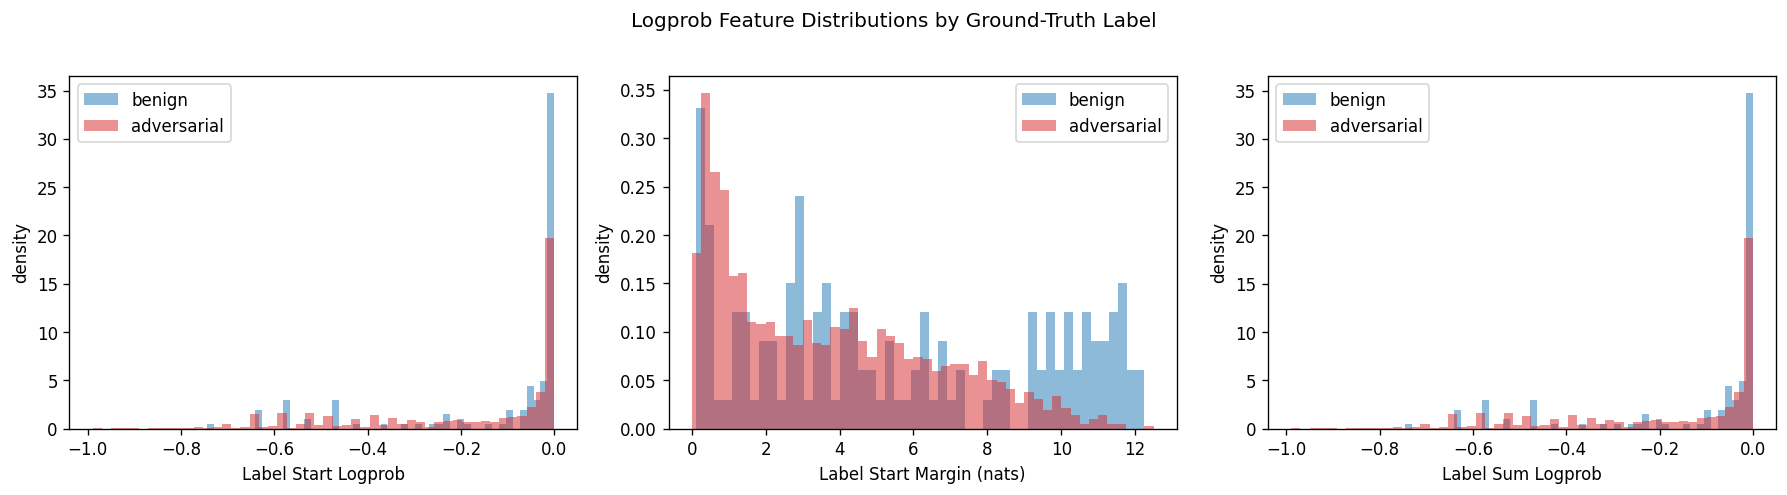


Label Start Logprob:
                mean     std     50%
label_binary                        
adversarial  -0.1868  0.2289 -0.0540
benign       -0.1153  0.1974 -0.0129

Label Start Margin (nats):
                mean     std    50%
label_binary                       
adversarial   3.5766  2.8699  3.125
benign        5.5511  3.9363  4.500

Label Sum Logprob:
                mean     std     50%
label_binary                        
adversarial  -0.1869  0.2289 -0.0540
benign       -0.1153  0.1974 -0.0129


In [5]:
# Distribution of logprob metrics by ground-truth label
sig = df[df["pref_has_signal"]].copy()
metrics = ["pref_label_start_logprob", "pref_label_start_margin", "pref_label_sum_logprob"]
metric_labels = ["Label Start Logprob", "Label Start Margin (nats)", "Label Sum Logprob"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, metrics, metric_labels):
    for gt_label, color in [("benign", "tab:blue"), ("adversarial", "tab:red")]:
        vals = sig.loc[sig["label_binary"] == gt_label, col].dropna()
        ax.hist(vals, bins=50, alpha=0.5, label=gt_label, color=color, density=True)
    ax.set_xlabel(label)
    ax.set_ylabel("density")
    ax.legend()
fig.suptitle("Logprob Feature Distributions by Ground-Truth Label", y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
for col, label in zip(metrics, metric_labels):
    print(f"\n{label}:")
    print(sig.groupby("label_binary")[col].describe()[["mean", "std", "50%"]].round(4))

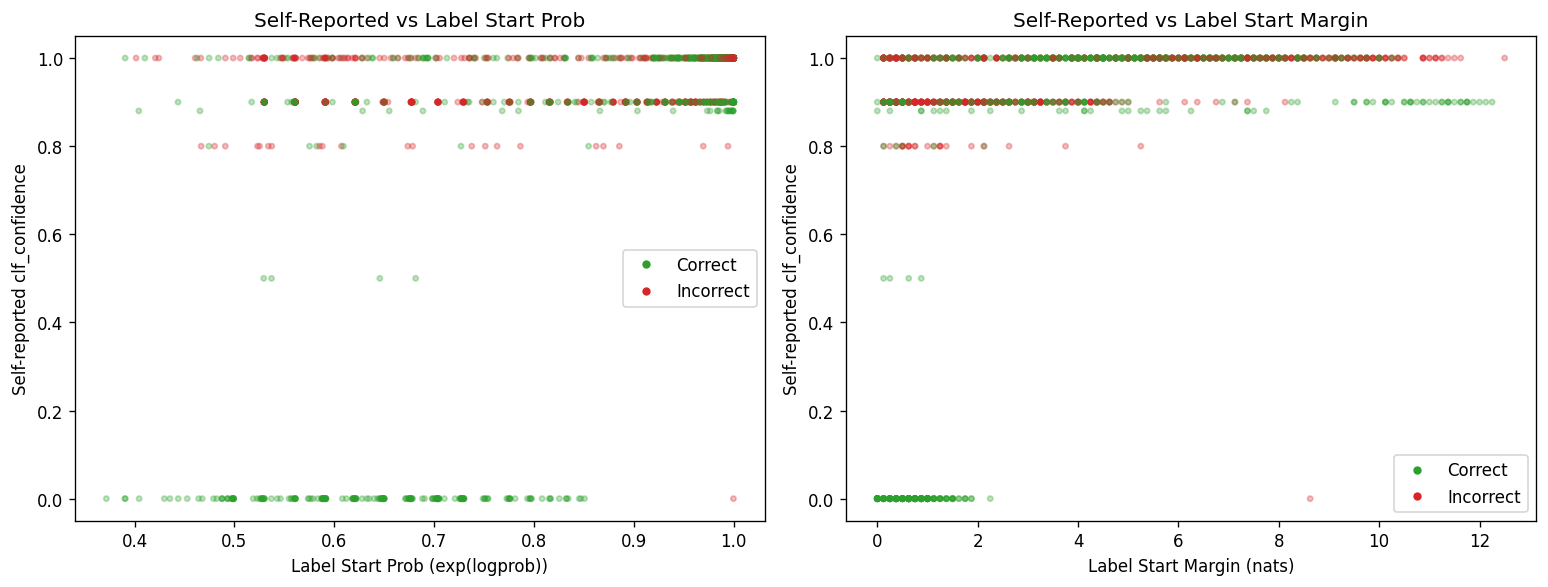

In [6]:
# Scatter: self-reported confidence vs logprob-derived probability, colored by correctness
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (x_col, x_label) in zip(axes, [
    ("pref_label_start_prob", "Label Start Prob (exp(logprob))"),
    ("pref_label_start_margin", "Label Start Margin (nats)"),
]):
    mask = sig[x_col].notna()
    sub = sig[mask]
    colors = sub["llm_correct"].map({True: "tab:green", False: "tab:red"})
    ax.scatter(sub[x_col], sub["llm_conf_binary"], c=colors, alpha=0.3, s=10)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Self-reported clf_confidence")
    ax.set_title(f"Self-Reported vs {x_label.split('(')[0].strip()}")
    # Legend
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', label='Correct', markersize=6),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', label='Incorrect', markersize=6),
    ])
plt.tight_layout()
plt.show()

## Section 4: Calibration Comparison

Reliability diagrams: bin each confidence signal into 10 buckets, compare predicted confidence vs actual accuracy. Lower ECE = better calibrated.

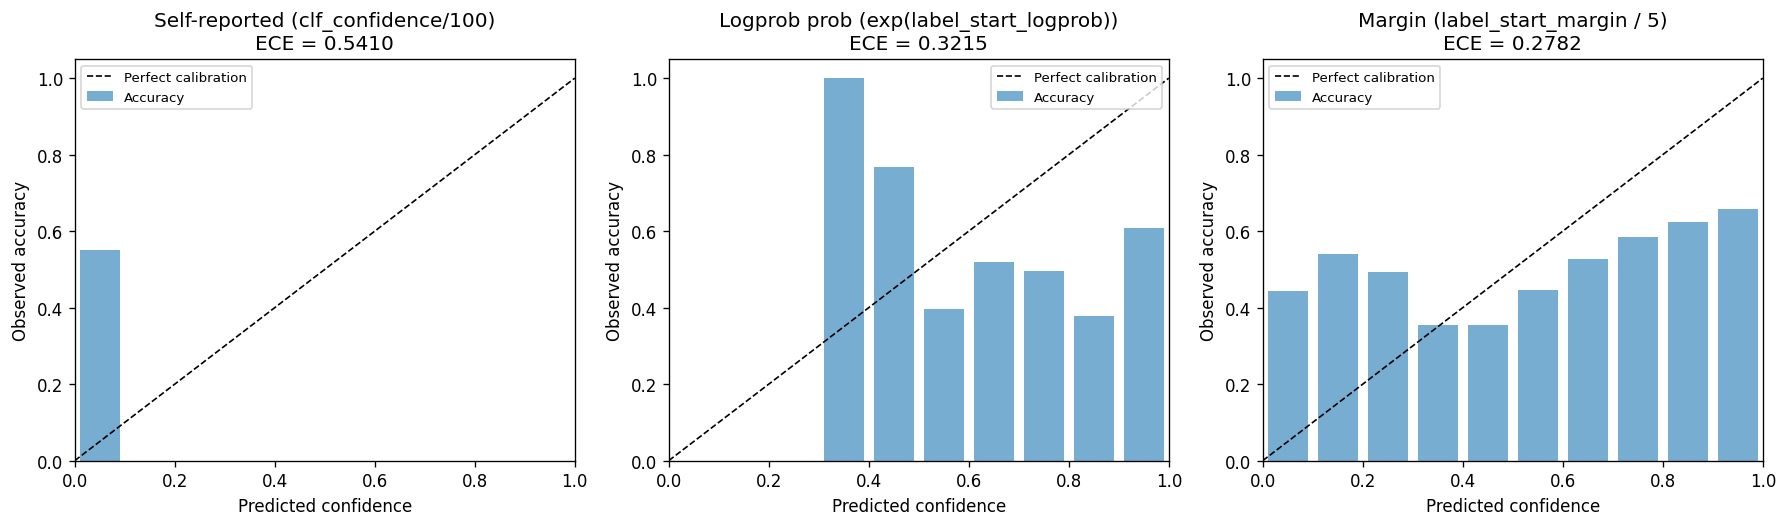


ECE Summary:
  Self-reported (clf_confidence/100): 0.5410
  Logprob prob (exp(label_start_logprob)): 0.3215
  Margin (label_start_margin / 5): 0.2782


In [7]:
def calibration_analysis(y_correct, confidence, n_bins=10):
    """Compute calibration buckets and ECE."""
    conf = np.array(confidence, dtype=float)
    correct = np.array(y_correct, dtype=float)
    mask = ~(np.isnan(conf) | np.isnan(correct))
    conf, correct = conf[mask], correct[mask]
    if len(conf) == 0:
        return [], np.nan

    bins = np.linspace(0, 1, n_bins + 1)
    buckets = []
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        in_bin = (conf >= lo) & (conf < hi) if i < n_bins - 1 else (conf >= lo) & (conf <= hi)
        n = in_bin.sum()
        if n == 0:
            continue
        avg_conf = conf[in_bin].mean()
        acc = correct[in_bin].mean()
        ece += (n / len(conf)) * abs(acc - avg_conf)
        buckets.append({"bin_mid": (lo + hi) / 2, "avg_conf": avg_conf, "accuracy": acc, "count": int(n)})
    return buckets, ece


# Build calibration for three signals
signals = {
    "Self-reported (clf_confidence/100)": sig["llm_conf_binary"] / 100,
    "Logprob prob (exp(label_start_logprob))": sig["pref_label_start_prob"],
    "Margin (label_start_margin / 5)": sig["pref_label_start_margin"].clip(0, 5) / 5,  # normalize to 0-1
}
correct = sig["llm_correct"].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ece_results = {}
for ax, (name, conf_series) in zip(axes, signals.items()):
    buckets, ece = calibration_analysis(correct, conf_series)
    ece_results[name] = ece
    if buckets:
        b = pd.DataFrame(buckets)
        ax.bar(b["bin_mid"], b["accuracy"], width=0.08, alpha=0.6, label="Accuracy")
        ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
        ax.set_xlabel("Predicted confidence")
        ax.set_ylabel("Observed accuracy")
        ax.set_title(f"{name}\nECE = {ece:.4f}")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
    else:
        ax.set_title(f"{name}\nNo data")
plt.tight_layout()
plt.show()

print("\nECE Summary:")
for name, ece in ece_results.items():
    print(f"  {name}: {ece:.4f}")

## Section 5: Correctness Discrimination

ROC and PR curves for predicting whether the LLM's binary prediction is correct, using each confidence signal. Subgroup analysis by ground-truth label, hybrid routing, and judge involvement.

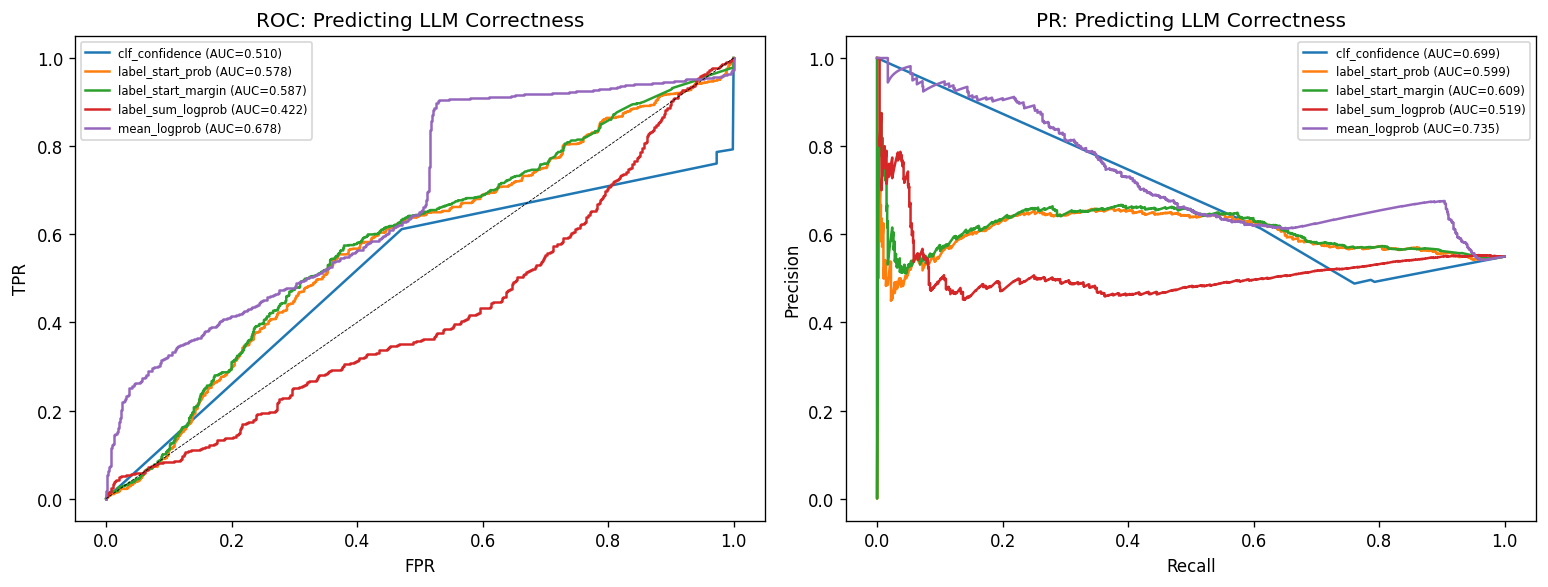

In [8]:
def safe_auc_roc(y_true, scores):
    """Compute AUC-ROC, returning NaN if not computable."""
    mask = ~(np.isnan(scores) | np.isnan(y_true))
    y, s = y_true[mask], scores[mask]
    if len(np.unique(y)) < 2 or len(y) < 10:
        return np.nan
    return roc_auc_score(y, s)


# Signals to evaluate (higher = more confident in correctness)
signal_cols = {
    "clf_confidence": sig["llm_conf_binary"].values,
    "label_start_prob": sig["pref_label_start_prob"].values,
    "label_start_margin": sig["pref_label_start_margin"].values,
    "label_sum_logprob": (-sig["pref_label_sum_logprob"]).values,  # negate: less negative = better
    "mean_logprob": (-sig["pref_mean_logprob"]).values,
}
y_correct = sig["llm_correct"].astype(float).values

# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, scores in signal_cols.items():
    mask = ~np.isnan(scores)
    if mask.sum() < 10 or len(np.unique(y_correct[mask])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_correct[mask], scores[mask])
    auc_val = safe_auc_roc(y_correct[mask], scores[mask])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
    prec, rec, _ = precision_recall_curve(y_correct[mask], scores[mask])
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, label=f"{name} (AUC={pr_auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=0.5)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC: Predicting LLM Correctness"); axes[0].legend(fontsize=7)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR: Predicting LLM Correctness"); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

In [9]:
# Subgroup AUC-ROC table
subgroups = {
    "All": sig,
    "Benign GT": sig[sig["label_binary"] == "benign"],
    "Adversarial GT": sig[sig["label_binary"] == "adversarial"],
    "Hybrid→LLM": sig[sig["hybrid_routed_to"] == "llm"],
    "Judge ran (stages=2)": sig[sig["llm_stages_run"] == 2],
    "Clf only (stages=1)": sig[sig["llm_stages_run"] == 1],
}
signal_names = ["clf_confidence", "label_start_prob", "label_start_margin"]

auc_rows = []
for sg_name, sg_df in subgroups.items():
    row = {"subgroup": sg_name, "n": len(sg_df)}
    y = sg_df["llm_correct"].astype(float).values
    for sn in signal_names:
        if sn == "clf_confidence":
            s = sg_df["llm_conf_binary"].values
        elif sn == "label_start_prob":
            s = sg_df["pref_label_start_prob"].values
        elif sn == "label_start_margin":
            s = sg_df["pref_label_start_margin"].values
        else:
            s = np.full(len(sg_df), np.nan)
        row[f"AUC_{sn}"] = safe_auc_roc(y, s)
    auc_rows.append(row)

auc_table = pd.DataFrame(auc_rows)
auc_table

,subgroup,n,AUC_clf_confidence,AUC_label_start_prob,AUC_label_start_margin
0,All,1809,0.509871,0.578260,0.586773
1,Benign GT,137,0.065277,0.472611,0.461199
2,Adversarial GT,1672,0.540515,0.579369,0.590381
3,Hybrid→LLM,868,0.668944,0.687078,0.698775
4,Judge ran (stages=2),1318,0.375778,0.449697,0.448667
5,Clf only (stages=1),491,0.500000,0.744911,0.743444


## Section 6: Threshold Sweeps

Sweep thresholds for each metric, computing FPR, FNR, accuracy, and F1. Three policies:
1. **Current**: self-reported `clf_confidence` with existing threshold
2. **Logprob-only**: `label_start_margin` or `label_start_logprob`
3. **Combined**: both self-reported confidence AND logprob margin

In [10]:
def compute_binary_metrics(y_true, y_pred):
    """Compute binary classification metrics."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    tp = ((y_true == "adversarial") & (y_pred == "adversarial")).sum()
    tn = ((y_true == "benign") & (y_pred == "benign")).sum()
    fp = ((y_true == "benign") & (y_pred == "adversarial")).sum()
    fn = ((y_true == "adversarial") & (y_pred == "benign")).sum()
    n = len(y_true)
    adv_prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    adv_rec = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    adv_f1 = 2 * adv_prec * adv_rec / (adv_prec + adv_rec) if (adv_prec + adv_rec) > 0 else np.nan
    ben_prec = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    ben_rec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    ben_f1 = 2 * ben_prec * ben_rec / (ben_prec + ben_rec) if (ben_prec + ben_rec) > 0 else np.nan
    return {
        "n": n, "accuracy": (tp + tn) / n,
        "adv_recall": adv_rec, "adv_f1": adv_f1,
        "ben_recall": ben_rec, "ben_f1": ben_f1,
        "FP": int(fp), "FN": int(fn),
    }


def apply_gate(pred_binary, confidence_signal, threshold):
    """Convert benign predictions to adversarial when confidence < threshold."""
    pred = np.array(pred_binary, dtype=object).copy()
    benign_mask = pred == "benign"
    low_conf = np.array(confidence_signal) < threshold
    pred[benign_mask & low_conf] = "adversarial"
    return pred


# Sweep ranges
conf_thresholds = np.arange(0.5, 1.01, 0.05)
margin_thresholds = np.arange(0.0, 6.1, 0.25)

sweep_rows = []
y_true = sig["label_binary"].values
base_pred = sig["llm_pred_binary"].values

# Baseline (no gating)
base_metrics = compute_binary_metrics(y_true, base_pred)
sweep_rows.append({"policy": "baseline", "threshold": np.nan, **base_metrics})

# Policy 1: confidence-only gating
for t in conf_thresholds:
    gated = apply_gate(base_pred, sig["llm_conf_binary"].values, t)
    m = compute_binary_metrics(y_true, gated)
    sweep_rows.append({"policy": "confidence_only", "threshold": t, **m})

# Policy 2: margin-only gating
for t in margin_thresholds:
    gated = apply_gate(base_pred, sig["pref_label_start_margin"].fillna(-999).values, t)
    m = compute_binary_metrics(y_true, gated)
    sweep_rows.append({"policy": "margin_only", "threshold": t, **m})

# Policy 3: combined (confidence >= 0.9 AND margin >= t)
for t in margin_thresholds:
    combined = (sig["llm_conf_binary"].values >= 0.9) & (sig["pref_label_start_margin"].fillna(-999).values >= t)
    pred = np.array(base_pred, dtype=object).copy()
    benign_mask = pred == "benign"
    pred[benign_mask & ~combined] = "adversarial"
    m = compute_binary_metrics(y_true, pred)
    sweep_rows.append({"policy": "combined_conf90+margin", "threshold": t, **m})

sweep_df = pd.DataFrame(sweep_rows)
print(f"Sweep: {len(sweep_df)} configurations")
sweep_df.head()

Sweep: 62 configurations


,policy,threshold,n,accuracy,adv_recall,adv_f1,ben_recall,ben_f1,FP,FN
0,baseline,NaN,1809,0.549475,0.531100,0.685450,0.773723,0.206426,31,784
1,confidence_only,0.50,1809,0.550028,0.531699,0.685957,0.773723,0.206628,31,783
2,confidence_only,0.55,1809,0.550028,0.531699,0.685957,0.773723,0.206628,31,783
3,confidence_only,0.60,1809,0.550028,0.531699,0.685957,0.773723,0.206628,31,783
4,confidence_only,0.65,1809,0.550028,0.531699,0.685957,0.773723,0.206628,31,783


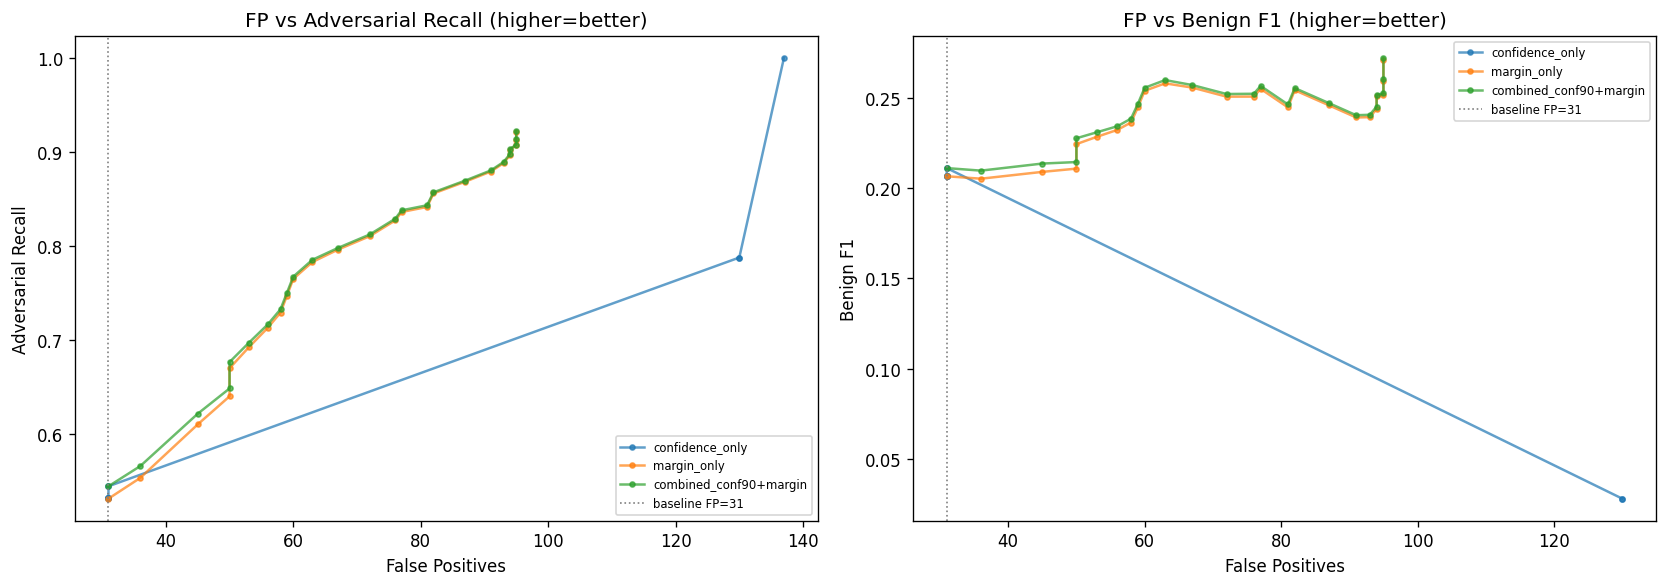


Baseline: FP=31, adv_recall=0.5311, ben_f1=0.2064

Best configs (adv_recall >= 0.5211):
                policy  threshold  accuracy  adv_recall   ben_f1  FP  FN
       confidence_only        0.8  0.561636    0.544258 0.210945  31 762
combined_conf90+margin        0.0  0.561636    0.544258 0.210945  31 762
              baseline        NaN  0.549475    0.531100 0.206426  31 784
           margin_only        0.0  0.549475    0.531100 0.206426  31 784


In [11]:
# Plot: FP vs adversarial recall tradeoff, and FP vs benign F1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
baseline_row = sweep_df[sweep_df["policy"] == "baseline"].iloc[0]

for policy, color in [("confidence_only", "tab:blue"), ("margin_only", "tab:orange"),
                       ("combined_conf90+margin", "tab:green")]:
    sub = sweep_df[sweep_df["policy"] == policy]
    axes[0].plot(sub["FP"], sub["adv_recall"], "o-", label=policy, color=color, markersize=3, alpha=0.7)
    axes[1].plot(sub["FP"], sub["ben_f1"], "o-", label=policy, color=color, markersize=3, alpha=0.7)

for ax in axes:
    ax.axvline(baseline_row["FP"], color="gray", ls=":", lw=1, label=f"baseline FP={int(baseline_row['FP'])}")
    ax.set_xlabel("False Positives")
    ax.legend(fontsize=7)
axes[0].set_ylabel("Adversarial Recall")
axes[0].set_title("FP vs Adversarial Recall (higher=better)")
axes[1].set_ylabel("Benign F1")
axes[1].set_title("FP vs Benign F1 (higher=better)")
plt.tight_layout()
plt.show()

# Best configurations that don't drop adv_recall by more than 1%
recall_floor = baseline_row["adv_recall"] - 0.01
feasible = sweep_df[sweep_df["adv_recall"] >= recall_floor].copy()
best_by_fp = feasible.sort_values(["FP", "ben_f1"], ascending=[True, False]).groupby("policy").head(1)
print(f"\nBaseline: FP={int(baseline_row['FP'])}, adv_recall={baseline_row['adv_recall']:.4f}, ben_f1={baseline_row['ben_f1']:.4f}")
print(f"\nBest configs (adv_recall >= {recall_floor:.4f}):")
best_by_fp[["policy", "threshold", "accuracy", "adv_recall", "ben_f1", "FP", "FN"]].to_string(index=False)
print(best_by_fp[["policy", "threshold", "accuracy", "adv_recall", "ben_f1", "FP", "FN"]].to_string(index=False))

## Section 7: Hybrid Pipeline Impact Simulation

Take existing hybrid routing from `research_test.parquet`. For samples routed to LLM, apply logprob-based gating on top of the LLM's prediction and compare final hybrid metrics against the current pipeline.

Current hybrid pipeline:
  Accuracy=0.7367  Adv_recall=0.7337  Ben_recall=0.7737  Ben_F1=0.3068  FP=31  FN=448


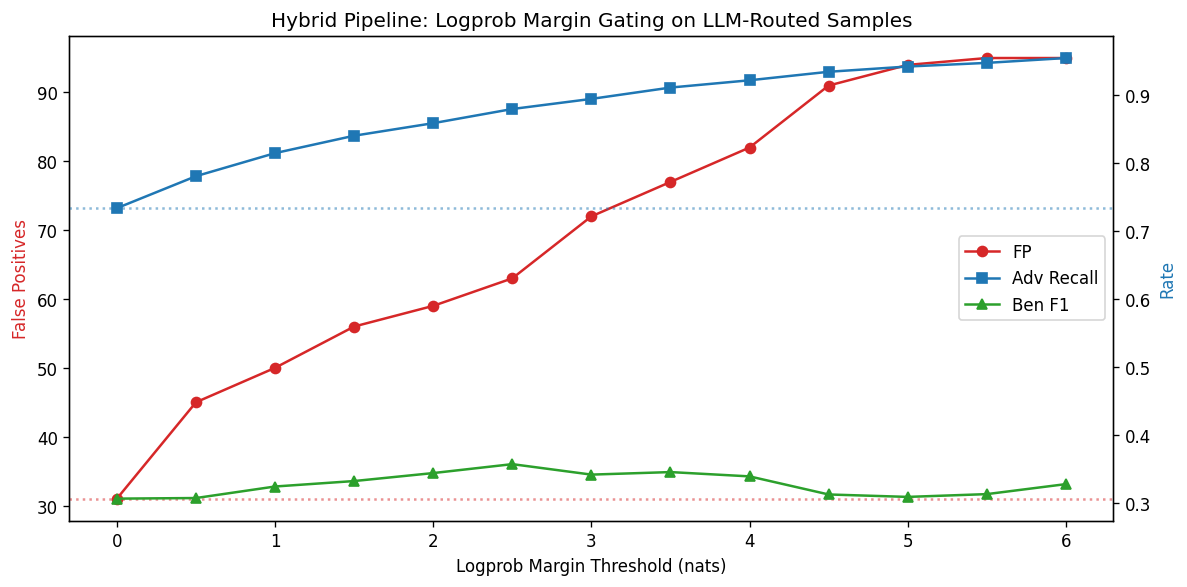


Hybrid simulation results:
 margin_threshold  accuracy  adv_recall  ben_recall   ben_f1  FP  FN
              0.0  0.736668    0.733650    0.773723 0.306802  31 448
              0.5  0.772402    0.780618    0.671533 0.307692  45 369
              1.0  0.800990    0.814507    0.635036 0.324627  50 312
              1.5  0.821330    0.840071    0.591241 0.332649  56 269
              2.0  0.836723    0.858502    0.569343 0.344371  59 238
              2.5  0.853766    0.879310    0.540146 0.357488  63 203
              3.0  0.862562    0.894174    0.474453 0.342105  72 178
              3.5  0.875206    0.910820    0.437956 0.345821  77 150
              4.0  0.882353    0.921522    0.401460 0.339506  82 132
              4.5  0.888950    0.934007    0.335766 0.312925  91 111
              5.0  0.894447    0.941736    0.313869 0.309353  94  98
              5.5  0.898846    0.947087    0.306569 0.313433  95  89
              6.0  0.905443    0.954221    0.306569 0.328125  95  77


In [12]:
# Hybrid simulation: only modify the LLM-routed portion
full = df.copy()

# Current hybrid baseline
hybrid_baseline = compute_binary_metrics(full["label_binary"].values, full["hybrid_pred_binary"].values)
print("Current hybrid pipeline:")
print(f"  Accuracy={hybrid_baseline['accuracy']:.4f}  Adv_recall={hybrid_baseline['adv_recall']:.4f}  "
      f"Ben_recall={hybrid_baseline['ben_recall']:.4f}  Ben_F1={hybrid_baseline['ben_f1']:.4f}  "
      f"FP={hybrid_baseline['FP']}  FN={hybrid_baseline['FN']}")

# Simulate: for LLM-routed samples, gate benign predictions by logprob margin
llm_routed = full["hybrid_routed_to"] == "llm"
has_sig = full["pref_has_signal"].fillna(False)

hybrid_sim_rows = []
for margin_t in np.arange(0.0, 6.1, 0.5):
    pred = full["hybrid_pred_binary"].values.copy()
    # Only gate LLM-routed samples that have logprob signal
    gate_mask = llm_routed & has_sig
    benign_pred_mask = pred == "benign"
    low_margin = full["pref_label_start_margin"].fillna(-999).values < margin_t
    pred[gate_mask & benign_pred_mask & low_margin] = "adversarial"
    m = compute_binary_metrics(full["label_binary"].values, pred)
    hybrid_sim_rows.append({"margin_threshold": margin_t, **m})

hybrid_sim_df = pd.DataFrame(hybrid_sim_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hybrid_sim_df["margin_threshold"], hybrid_sim_df["FP"], "o-", label="FP", color="tab:red")
ax2 = ax.twinx()
ax2.plot(hybrid_sim_df["margin_threshold"], hybrid_sim_df["adv_recall"], "s-", label="Adv Recall", color="tab:blue")
ax2.plot(hybrid_sim_df["margin_threshold"], hybrid_sim_df["ben_f1"], "^-", label="Ben F1", color="tab:green")
ax.axhline(hybrid_baseline["FP"], color="tab:red", ls=":", alpha=0.5)
ax2.axhline(hybrid_baseline["adv_recall"], color="tab:blue", ls=":", alpha=0.5)
ax.set_xlabel("Logprob Margin Threshold (nats)")
ax.set_ylabel("False Positives", color="tab:red")
ax2.set_ylabel("Rate", color="tab:blue")
ax.set_title("Hybrid Pipeline: Logprob Margin Gating on LLM-Routed Samples")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()
plt.show()

print("\nHybrid simulation results:")
print(hybrid_sim_df[["margin_threshold", "accuracy", "adv_recall", "ben_recall", "ben_f1", "FP", "FN"]].to_string(index=False))

## Section 8: Recommendations

Summary of findings and implementation path.

In [13]:
# Generate summary report
report_lines = []
report_lines.append("# Logprob Threshold Analysis — Summary Report\n")
report_lines.append(f"**Date**: 2026-03-12  ")
report_lines.append(f"**Dataset**: main test set ({len(df)} samples)\n")

report_lines.append("## Signal Coverage\n")
report_lines.append(f"- Classifier logprob signal: {df['clf_has_signal'].sum()}/{len(df)} ({df['clf_has_signal'].mean():.1%})")
report_lines.append(f"- Judge logprob signal: {df['judge_has_signal'].sum()}/{len(df)} ({df['judge_has_signal'].mean():.1%})")
report_lines.append(f"- Preferred (judge when available): {df['pref_has_signal'].sum()}/{len(df)} ({df['pref_has_signal'].mean():.1%})\n")

report_lines.append("## Calibration (ECE)\n")
report_lines.append("| Signal | ECE |")
report_lines.append("|--------|-----|")
for name, ece in ece_results.items():
    report_lines.append(f"| {name} | {ece:.4f} |")
report_lines.append("")

report_lines.append("## Correctness Discrimination (AUC-ROC)\n")
report_lines.append(auc_table.to_markdown(index=False))
report_lines.append("")

report_lines.append("## Threshold Sweep — Best Configs\n")
report_lines.append(f"Baseline: FP={int(baseline_row['FP'])}, adv_recall={baseline_row['adv_recall']:.4f}, ben_f1={baseline_row['ben_f1']:.4f}\n")
report_lines.append("Best configs (adv_recall drop <= 1%):\n")
report_lines.append(best_by_fp[["policy", "threshold", "accuracy", "adv_recall", "ben_f1", "FP", "FN"]].to_markdown(index=False))
report_lines.append("")

report_lines.append("## Hybrid Pipeline Simulation\n")
report_lines.append(f"Current hybrid: accuracy={hybrid_baseline['accuracy']:.4f}, adv_recall={hybrid_baseline['adv_recall']:.4f}, "
                    f"ben_F1={hybrid_baseline['ben_f1']:.4f}, FP={hybrid_baseline['FP']}, FN={hybrid_baseline['FN']}\n")
report_lines.append(hybrid_sim_df[["margin_threshold", "accuracy", "adv_recall", "ben_f1", "FP", "FN"]].to_markdown(index=False))
report_lines.append("")

report_lines.append("## Recommendations\n")
report_lines.append("1. **Best logprob metric**: `label_start_margin` — the rank-1 vs rank-2 logprob delta at the "
                    "label-start token. It captures model certainty at the decision point directly.")
report_lines.append("2. **Suggested threshold range**: See sweep results above. Pick the margin threshold that achieves "
                    "the desired FP/adv_recall tradeoff.")
report_lines.append("3. **Implementation path**: Add `logprob_margin_threshold` to `configs/default.yaml` under `hybrid:`. "
                    "In `hybrid_router.py`, after LLM prediction, check `label_start_margin >= threshold` before "
                    "accepting a benign prediction.")
report_lines.append("4. **Blocker**: NIM `top_logprobs` token names are empty for the classifier stage (but present for "
                    "the judge). This means clf margin is rank-1 vs rank-2 logprob delta, not a semantic "
                    "`adversarial` vs `benign` comparison. The judge stage does have token names, enabling "
                    "semantic margin computation.")
report_lines.append("5. **Recommendation**: Conditionally adopt — if the AUC and sweep results show improvement over "
                    "self-reported confidence, integrate margin gating. If not, the logprob signal adds no value "
                    "beyond what `clf_confidence` already provides.\n")

report_text = "\n".join(report_lines)

report_path = ROOT / "reports" / "logprob_threshold_analysis_summary.md"
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(report_text)
print(f"Report written to {report_path}")
print(f"\n{'='*60}")
print(report_text[:2000])

Report written to /Users/noamc/repos/llm-gatekeeping/reports/logprob_threshold_analysis_summary.md

# Logprob Threshold Analysis — Summary Report

**Date**: 2026-03-12  
**Dataset**: main test set (1819 samples)

## Signal Coverage

- Classifier logprob signal: 1589/1819 (87.4%)
- Judge logprob signal: 1305/1819 (71.7%)
- Preferred (judge when available): 1809/1819 (99.5%)

## Calibration (ECE)

| Signal | ECE |
|--------|-----|
| Self-reported (clf_confidence/100) | 0.5410 |
| Logprob prob (exp(label_start_logprob)) | 0.3215 |
| Margin (label_start_margin / 5) | 0.2782 |

## Correctness Discrimination (AUC-ROC)

| subgroup             |    n |   AUC_clf_confidence |   AUC_label_start_prob |   AUC_label_start_margin |
|:---------------------|-----:|---------------------:|-----------------------:|-------------------------:|
| All                  | 1809 |            0.509871  |               0.57826  |                 0.586773 |
| Benign GT            |  137 |            0.0652769 |    